In [1]:
import numpy as np
import matplotlib.pyplot as plt

List_methode_de_flux= ["Roe","Rusanov","Godunov"]
List_condition_limite=["Neumann","Dirichlet","Periodique"]

In [ ]:

class Finite_Volume:


    def __init__(self,u0,function, derivee_de_la_function, flux_methode, film_bool =False, condition_limite = "Neumann",  ghost_nodes=[0,0], domaine=(0,1) ):
        Valid_init = True
        self.function = function; self.derivee_de_la_function = derivee_de_la_function; self.flux = lambda u,v:0*u+0*v

        in_list =False
        for methode in List_methode_de_flux:
            if(flux_methode ==methode):  in_list =True
        if(not in_list): Valid_init = False

        in_list =False
        for condition in List_condition_limite:
            if(condition_limite ==condition): in_list =True
        if(not in_list): Valid_init = False
        
    
        self.flux_methode = flux_methode;   self.condition_limite = condition_limite
        self.ghost_nodes=ghost_nodes
        self.u0=u0
        self.film_bool = film_bool
        self.domaine= domaine
        if(not Valid_init): f"Methode non reconnue"
        
    def g_godunov(self, u,v):
        U = np.linspace(u, v, 10)
        if(u<v):    return np.min(self.function(U))
        else :      return np.max(self.function(U))

    def flux_function(self,problem):
        
        if(self.flux_methode == "Godunov"): 
            if(problem =="Burgers"): self.flux= lambda u,v :  (0 if (u*v<0 and self.function(1)>0)  else min(self.function(u),self.function(v))) if u<v else (0 if(u*v<0 and self.function(1)<0) else max(self.function(u),self.function(v)))
            elif(problem =="cubique"): self.flux= lambda u,v : min(self.function(u),self.function(v)) if u<v else max(self.function(u),self.function(v))
            else : 
                self.flux= lambda u,v : self.g_godunov(u,v)
        elif(self.flux_methode == "Rusanov"):
            self.flux= lambda u,v : 0.5*(self.function(u)+self.function(v))-0.5*max(np.abs(self.derivee_de_la_function(u)), np.abs(self.derivee_de_la_function(v)))*(v-u)
        elif(self.flux_methode == "Roe"):
            self.flux= lambda u,v : (0.5*(self.function(u)+self.function(v))-0.5*np.abs(self.derivee_de_la_function(u))*(v-u))*(u==v) + (self.function(u)-self.function(v))*(v<u)

    
    def show_solution_xt(self,t):
        fig, ax = plt.subplots()
        im = ax.imshow(self.solution_xt,extent=((self.domaine[0],self.domaine[1],0,t)))
        fig.colorbar(im, ax=ax, label='Interactive colorbar')
        ax.set_ylabel("t")
        ax.set_xlabel("x")
        plt.show()
    
    def show_solution(self,t):
        X = np.linspace(self.domaine[0],self.domaine[1], len(self.solution))
        plt.plot(X,self.solution,'-r')
        plt.title(f"solution at time {t}")
        plt.show()

    def sol(self, J,T,  CFL=0.95):
        dx = 1./J
        X = np.linspace(self.domaine[0]+dx,self.domaine[1],J) -dx/2

        f = self.function; f_p = self.derivee_de_la_function; g = self.flux
        U = self.u0(X)

        FG = np.empty_like(X) 
        FD = np.empty_like(X)

        Film=[]; F=[[],[]]  

        t=0.; n =0; dt=0.
        while t<T and n<10000:
            #calcul de dt
            vitesse = max(abs(f_p(U)))
            if(vitesse !=0) : dt = (min(CFL * dx /(2* vitesse), T-t))
            else :            dt = CFL*dx  

            if(dt<0): dt = 10e-10; print(f"!!!!!!!!!!!!!!!!! dt<0 !!!!!!!!!")

            ## Calcul du flux
            for j in range(len(X)):
                
                if(j==0):   
                    if(self.condition_limite =="Dirichlet"):    FG[j] = g(self.ghost_nodes[0],       U[j])
                    elif(self.condition_limite =="Neumann"):    FG[j] = g(U[j]+self.ghost_nodes[0],U[j])
                    elif(self.condition_limite =="Periodique"): FG[j] = g(U[-1], U[j])

                else :      FG[j]= g(U[j-1],U[j]); 
                
                if(j==J-1):   
                    if(self.condition_limite =="Dirichlet"):    FD[j] = g(U[j], self.ghost_nodes[1])
                    elif(self.condition_limite =="Neumann"):    FD[j] = g(U[j], U[j]+self.ghost_nodes[1])
                    elif(self.condition_limite =="Periodique"): FD[j] = g(U[j], U[0])

                else :      FD[j]= g(U[j],U[j+1]) 
               
            ## Calcul de la solution
            for j in range(len(X)):
                U[j] = U[j] -(dt/dx)* (FD[j]-FG[j])

            if(self.film_bool): Film.append(U.copy()); F[0].append(FD.copy()); F[1].append(FG.copy())
            n+=1; t+= dt
        
        if(self.film_bool): 
            U_xt = np.zeros((len(Film),len(U)))
            for i in range(len(Film)-1) : U_xt[i,:] = Film[-i]
            self.solution_xt = U_xt
            self.show_solution_xt(T)
        else:   
            self.solution= U
            self.show_solution(T)

        

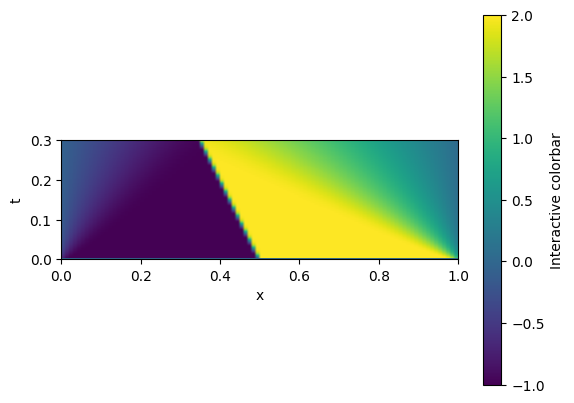

In [3]:
#
ul=-1.;ur=2.
U0  = lambda x: ul*(x<0.5) + ur*(x>=0.5)
f  = lambda u: -0.5* u**2
f_p= lambda u: -u

J,T = 100,0.3

Fv = Finite_Volume(U0,function=f,derivee_de_la_function=f_p,flux_methode="Godunov",film_bool=True, condition_limite="Periodique")
Fv.flux_function("Cubique")
Fv.sol(J,T,CFL=0.9)


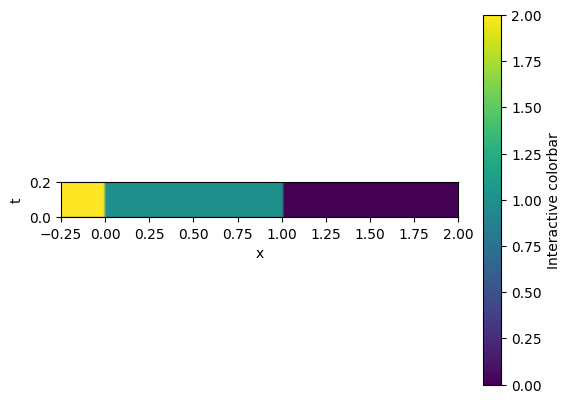

In [61]:
#
# U0  = lambda x: ul*(x<0.5) + ur*(x>=0.5)
U0 = lambda x: 2*(x<0) + 1*(0<x)*(x<1)
f  = lambda u: u**2
f_p= lambda u: 2*u

J,T = 100,0.2
a,b=-0.25,2
Fv = Finite_Volume(U0,function=f,derivee_de_la_function=f_p,flux_methode="Godunov",film_bool=True, condition_limite="Neumann", domaine=(a,b))
Fv.flux_function("")
Fv.sol(J,T,CFL=0.5)

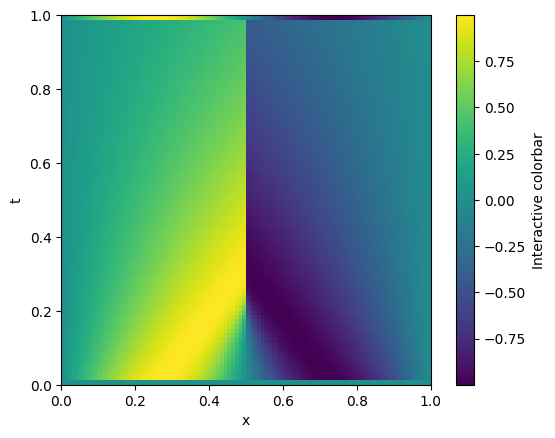

In [5]:
#
U0  = lambda x: np.sin(2*np.pi*x)
f  = lambda u: 0.5* u**2
f_p= lambda u: u

J,T = 100,1

Fv = Finite_Volume(U0,function=f,derivee_de_la_function=f_p,flux_methode="Godunov",film_bool=True, condition_limite="Periodique")
Fv.flux_function("Cubique")
Fv.sol(J,T,CFL=1.9)

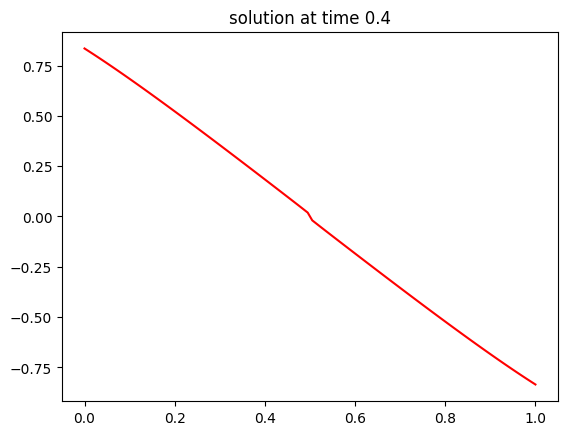

In [6]:
#
U0  = lambda x: np.sin(2*np.pi*x)
f  = lambda u: -0.5* u**2
f_p= lambda u: -u

J,T = 100,0.4

Fv = Finite_Volume(U0,function=f,derivee_de_la_function=f_p,flux_methode="Godunov",film_bool=False, condition_limite="Periodique")
Fv.flux_function("Cubique")
Fv.sol(J,T,CFL=1.9)

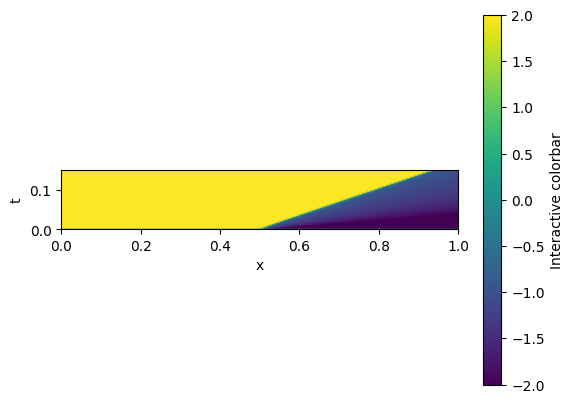

In [7]:
#
ul=2.;ur=-2.
U0  = lambda x: ul*(x<0.5) + ur*(x>=0.5)
f  = lambda u: u**3
f_p= lambda u: 3* u**2

J,T = 100,0.15

Fv = Finite_Volume(U0,function=f,derivee_de_la_function=f_p,flux_methode="Godunov",film_bool=True, condition_limite="Neumann")
Fv.flux_function("Cubique")
Fv.sol(J,T,CFL=1.9)